In [3]:
import numpy as np
import xgboost as xgb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from lifelines.utils import concordance_index

In [4]:
df_improvement = pd.read_csv("dataset/df_clean.csv")

# Although XGBoost doesn't need scaled inputs, put it anyways to ensure fairness for comparison between baseline and improved model
df_improvement["Minutes of Use"] = df_improvement["Seconds of Use"] / 60
df_improvement["Charge Amount/10"] = df_improvement["Charge  Amount"] / 10
df_improvement = df_improvement.drop(columns=["Seconds of Use", "Charge  Amount"])

print(f"Shape: {df_improvement.shape}")
df_train, df_test = train_test_split(df_improvement, test_size=0.4, stratify=df_improvement['Status'], random_state=42)
print(f"Shape for training set: {df_train.shape}")
print(f"Shape for test set: {df_test.shape}")

Shape: (2850, 14)
Shape for training set: (1710, 14)
Shape for test set: (1140, 14)


In [5]:
# Drop the targets for X so that it prevents data leakage 
X_train = df_train.drop(columns=["Subscription  Length", "Churn"])

# DMatrix just makes the XGB perform faster later during training
dtrain = xgb.DMatrix(X_train)

# Setting up the boundaries
# We know that no customers churned before the end of their Subscription Length (so it becomes the lower bound)
y_lower_bound = df_train['Subscription  Length'].values

# Where function is like the if() function, params are (condition, result if positive, result if negative)
# Let's say if the result is positive, the model knows the customer will churn eventually, 
# but in the meantime, assume they churn between month of their subs length and month infinity or forever
# if negative, it means they churned around the month of their subs length
y_upper_bound = np.where(df_train['Churn'] == 0, np.inf, df_train['Subscription  Length'].values)

dtrain.set_float_info('label_lower_bound', y_lower_bound)
dtrain.set_float_info('label_upper_bound', y_upper_bound)

X_test = df_test.drop(columns=["Subscription  Length", "Churn"])
dtest = xgb.DMatrix(X_test)

y_lower_test = df_test['Subscription  Length'].values
y_upper_test = np.where(df_test['Churn'] == 0, np.inf, df_test['Subscription  Length'].values)

dtest.set_float_info('label_lower_bound', y_lower_test)
dtest.set_float_info('label_upper_bound', y_upper_test)

In [ ]:
# Hyperparameter dictionary for survival analysis
parameters = {
    'objective': 'survival:aft',
    'eval_metric': 'aft-nloglik',
    'aft_loss_distribution': 'normal',
    'learning_rate': 0.01,
    'max_depth': 8,
    'min_child_weight': 10
}

# The paramaters are picked from Random Search, Random Search is used because it's more computationally efficient than Grid Search
# And it experiments a broader range of values of each hyperparameter 
# rather than keep on testing the same significant parameter with different values of insignificant ones (Grid Search does that)

# Write evals here just for neatness
evals = [(dtrain, 'train'), (dtest, 'test')]

xgb_model = xgb.train(
    params=parameters, 
    dtrain=dtrain, 
    num_boost_round=500, 
    evals=evals, 
    early_stopping_rounds=20,
    verbose_eval=10  
)

[0]	train-aft-nloglik:11.05747	test-aft-nloglik:10.99837
[10]	train-aft-nloglik:9.32387	test-aft-nloglik:9.28485
[20]	train-aft-nloglik:7.89375	test-aft-nloglik:7.87190
[30]	train-aft-nloglik:6.71249	test-aft-nloglik:6.70534
[40]	train-aft-nloglik:5.73548	test-aft-nloglik:5.74100
[50]	train-aft-nloglik:4.92623	test-aft-nloglik:4.94244
[60]	train-aft-nloglik:4.25488	test-aft-nloglik:4.27961
[70]	train-aft-nloglik:3.69697	test-aft-nloglik:3.72849
[80]	train-aft-nloglik:3.23241	test-aft-nloglik:3.26954
[90]	train-aft-nloglik:2.84489	test-aft-nloglik:2.88758
[100]	train-aft-nloglik:2.52093	test-aft-nloglik:2.56883
[110]	train-aft-nloglik:2.24959	test-aft-nloglik:2.30197
[120]	train-aft-nloglik:2.02174	test-aft-nloglik:2.07767
[130]	train-aft-nloglik:1.82994	test-aft-nloglik:1.88922
[140]	train-aft-nloglik:1.66814	test-aft-nloglik:1.73056
[150]	train-aft-nloglik:1.53139	test-aft-nloglik:1.59661
[160]	train-aft-nloglik:1.41567	test-aft-nloglik:1.48366
[170]	train-aft-nloglik:1.31675	test-aft

In [ ]:
predicted_time = xgb_model.predict(dtest)

# Evaluation after predicting
c_index = concordance_index(
    event_times = df_test["Subscription  Length"],
    predicted_scores = predicted_time,  
    event_observed = df_test["Churn"]
)

print(f"\n~ FINAL RESULTS ~")
print(f"XGBoost AFT (Optimized) C-Index: {c_index:.4f}")


~ FINAL RESULTS ~
XGBoost AFT (Optimized) C-Index: 0.9324


<Figure size 1000x600 with 0 Axes>

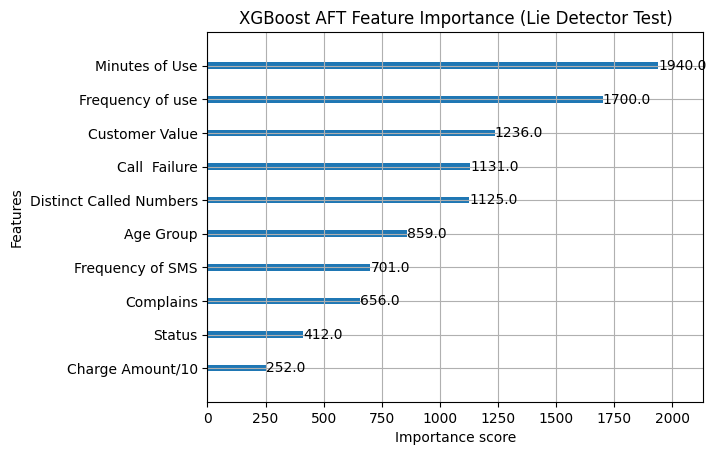

In [ ]:
# Plot on how important the features are in the output
plt.figure(figsize=(10, 6))
xgb.plot_importance(
    xgb_model, 
    max_num_features=10, 
    importance_type='weight',
    title='XGBoost AFT Feature Importance'
)
plt.show()